# 11 · Ad exposure is self-selected — the true effect (instrumental variables · CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The decision.** People who see our ads convert more — but engaged customers also seek
us out, so **exposure is self-selected**. A plain regression of sales on exposure is
biased upward (it credits the ad for the engagement that caused the exposure). What's
the *true* exposure→sales effect, so we can set budgets and frequency caps?

**Instrumental variables** break the self-selection. We use a randomized
**encouragement** (e.g. a serving-priority lottery) that moves *exposure* but has no
other path to sales. The part of exposure the instrument drives is as-good-as-random, so
its relationship to sales identifies the causal effect — for the **compliers** (LATE).

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 37

## 2 · Simulate a ground truth

The **true** exposure→sales effect is **€15**. But an unobserved `engagement` drives
both exposure and sales, so naive OLS will overstate it. A randomized `encouragement`
(the instrument) nudges exposure without touching sales directly.


In [2]:
df, true_effect = dgp.iv_ad_exposure(n=3000, true_effect=15.0, seed=SEED)
print(f"TRUE exposure → sales effect = €{true_effect:.0f}")
# first-stage strength: does the instrument actually move exposure?
first_stage = df.groupby("encouragement")["ad_exposure"].mean()
print(f"exposure rate — not encouraged {first_stage[0]:.0%}, encouraged {first_stage[1]:.0%} "
      f"(first-stage shift {first_stage[1]-first_stage[0]:+.0%})")
df.head()

TRUE exposure → sales effect = €15
exposure rate — not encouraged 56%, encouraged 77% (first-stage shift +21%)


,encouragement,ad_exposure,sales
0,1.0,0.0,63.748992
1,1.0,1.0,64.636639
2,1.0,1.0,46.507627
3,0.0,1.0,75.599770
4,0.0,1.0,70.577754


## 3 · Identify — a valid instrument, and what IV recovers

Exposure is **endogenous**: $\text{Cov}(\text{exposure}, \varepsilon)\neq 0$, so OLS is
biased. A valid instrument $Z$ (encouragement) needs three things:

- **Relevance** — $Z$ actually moves exposure (checked above: the first-stage shift).
- **Exclusion** — $Z$ affects sales *only through* exposure (the lottery doesn't sell
  anything by itself).
- **Exogeneity** — $Z$ is independent of the unobserved confounder (it's randomized).

**What IV identifies — LATE (Imbens–Angrist):** under monotonicity (no "defiers"), IV
recovers the effect for **compliers** — the customers whose exposure the instrument
moves — not the whole population. Report it as such. CausalPy fits a Bayesian IV: a
joint model of (exposure, sales) with correlated errors, estimating the endogeneity
$\rho$ rather than assuming it away.


## 4 · Estimate — naive OLS vs Bayesian IV

In [3]:
# naive OLS (biased by self-selection)
Xo = np.column_stack([np.ones(len(df)), df["ad_exposure"].values])
naive = np.linalg.lstsq(Xo, df["sales"].values, rcond=None)[0][1]

result = est.iv(df, "ad_exposure ~ 1 + encouragement", "sales ~ 1 + ad_exposure",
                instrument_col="encouragement", treatment_col="ad_exposure", outcome_col="sales", fast=FAST)
iv_post = result.idata.posterior["beta_z"].sel(covariates="ad_exposure").values.ravel()
print(f"Naive OLS effect  €{naive:.1f}   (biased UP by self-selection)")
print(f"Bayesian IV effect €{iv_post.mean():.1f}   (true €{true_effect:.0f})   "
      f"90% CI [€{np.quantile(iv_post,0.05):.1f}, €{np.quantile(iv_post,0.95):.1f}]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [beta_t, beta_z, chol_cov]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 6 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Naive OLS effect  €23.7   (biased UP by self-selection)
Bayesian IV effect €16.6   (true €15)   90% CI [€15.5, €17.8]


## 5 · Validate — IV corrects the self-selection bias

Naive OLS should sit well *above* the truth (it credits the ad for the engagement that
drove exposure); IV should land near €15. The gap between them is the self-selection
bias the instrument removes.


self-selection bias removed: naive €23.7 → IV €16.6 (true €15)


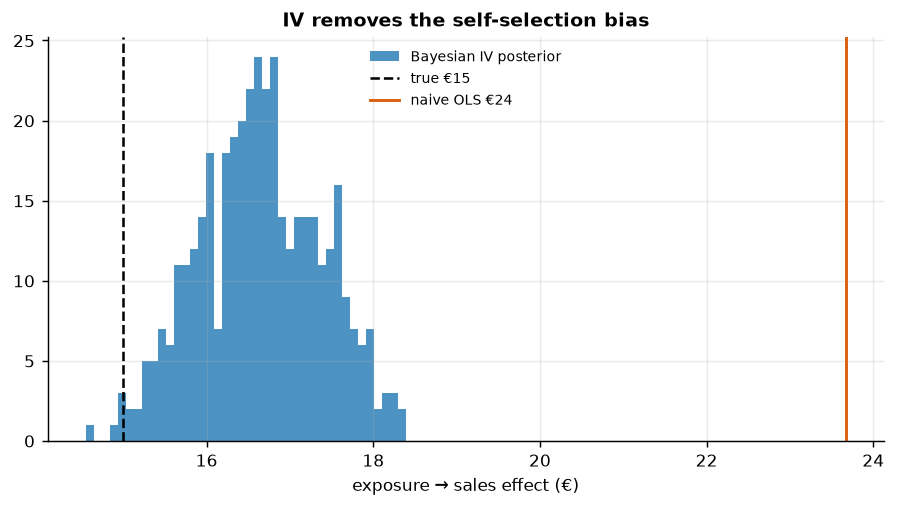

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(iv_post, bins=40, color=plots.BLUE, alpha=0.85, label="Bayesian IV posterior")
ax.axvline(true_effect, color="k", ls="--", lw=1.4, label=f"true €{true_effect:.0f}")
ax.axvline(naive, color=plots.ORANGE, lw=1.6, label=f"naive OLS €{naive:.0f}")
ax.set_xlabel("exposure → sales effect (€)"); ax.set_title("IV removes the self-selection bias")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"self-selection bias removed: naive €{naive:.1f} → IV €{iv_post.mean():.1f} (true €{true_effect:.0f})")

## 6 · Decide, in euros — budget and frequency caps

Use the *causal* per-exposure value (not the inflated naive one) to set spend. Budgeting
on the naive number would over-invest in exposure that isn't actually driving the sales.


In [5]:
COST_PER_EXPOSURE = 10.0    # € to serve one incremental exposure
net = iv_post - COST_PER_EXPOSURE
p_worth = (net > 0).mean()
naive_net = naive - COST_PER_EXPOSURE
print(f"Causal net value per exposure  €{net.mean():.1f}  (IV effect − €{COST_PER_EXPOSURE:.0f} cost)")
print(f"P(exposure pays)               {p_worth:.2f}  → " + ("BUY exposure (to the complier margin)" if p_worth>0.9 else "hold"))
print(f"\nIf we'd trusted naive OLS (€{naive:.0f}), we'd have booked €{naive_net:.0f}/exposure of value")
print(f"that mostly isn't causal — over-spending and setting frequency caps too high.")

Causal net value per exposure  €6.6  (IV effect − €10 cost)
P(exposure pays)               1.00  → BUY exposure (to the complier margin)

If we'd trusted naive OLS (€24), we'd have booked €14/exposure of value
that mostly isn't causal — over-spending and setting frequency caps too high.


## 7 · Caveats

- **LATE, not ATE.** IV speaks only for **compliers** — customers the encouragement
  actually moves. If your always-exposed loyalists or never-exposed skeptics respond
  differently, the number doesn't transfer to them. Report the scope.
- **Weak instruments are dangerous.** A small first-stage shift inflates variance and
  bias. Check first-stage strength (we did); a weak instrument is worse than none.
- **Exclusion is untestable and easy to violate.** If the encouragement itself nudges
  sales (e.g. the lottery email also advertises), the estimate is contaminated. Defend
  exclusion on design grounds, not data.
- **Monotonicity (no defiers).** IV's LATE interpretation assumes no one is pushed
  *away* from exposure by encouragement. Usually plausible, worth stating.
